In [17]:
!nvidia-smi

Fri Feb 27 11:40:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
| 41%   63C    P0            208W /  450W |    9797MiB /  24564MiB |     74%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
%pip install torch torchvision
%pip install nvidia-ml-py
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [19]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


In [20]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
])


train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [22]:
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd.profiler import record_function

class ProfileCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.conv3 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(64 * 1 * 1, 512)
        self.fc2 = nn.Linear(512, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):

        with record_function("layer_conv1"):
            x = F.relu(self.conv1(x))
            x = F.max_pool2d(x, 2)

        with record_function("layer_conv2"):
            x = F.relu(self.conv2(x))
            x = F.max_pool2d(x, 2)

        with record_function("layer_conv3"):
            x = F.relu(self.conv3(x))
            x = F.max_pool2d(x, 2)

        with record_function("layer_fc1"):
            x = x.view(x.size(0), -1)
            x = F.relu(self.fc1(x))
        
        with record_function("layer_fc2"):
            x = self.fc2(x)
            x = F.relu(x)

        with record_function("layer_fc3"):
            x = self.fc3(x)

        return x

Start by training with real-time monitoring over 10 epochs

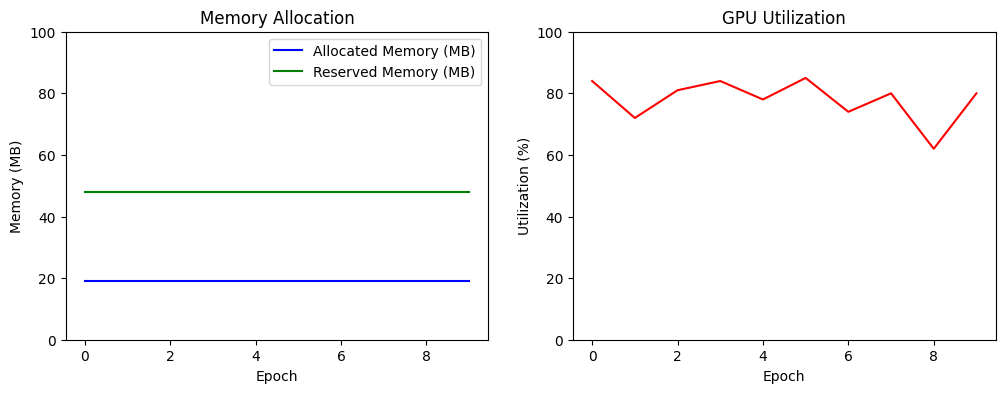

In [23]:
import pynvml
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = "cuda"
pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)

model = ProfileCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

allocated_history = []
reserved_history = []
utilization_history = []

for epoch in range(10):
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        allocated_mb = torch.cuda.memory_allocated() / (1024 ** 2)
        reserved_mb = torch.cuda.memory_reserved() / (1024 ** 2)
        utilization_percent = pynvml.nvmlDeviceGetUtilizationRates(handle).gpu

    allocated_history.append(allocated_mb)
    reserved_history.append(reserved_mb)
    utilization_history.append(utilization_percent)

    if epoch % 1 == 0:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
        
        ax1.plot(allocated_history, label='Allocated Memory (MB)', color='blue')
        ax1.plot(reserved_history, label='Reserved Memory (MB)', color='green')
        ax1.set_title('Memory Allocation')  
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Memory (MB)')
        ax1.set_ylim(0, 100)
        ax1.legend()

        ax2.plot(utilization_history, label='GPU Utilization (%)', color='red')
        ax2.set_title('GPU Utilization')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Utilization (%)')
        ax2.set_ylim(0, 100)
        
        plt.show()

# Save the figure to a SVG image after displaying it for easy inclusion in documents
fig.savefig("gpu_profile_plot.svg", format="svg")


Profile the network without training

layer_conv1 486.3140000000021 19382272
layer_conv2 258.1270000000004 7995392
layer_conv3 240.9380000000001 786432
layer_fc1 251.11999999999898 524288
layer_fc2 150.0699999999997 65536
layer_fc3 88.31400000000212 10240


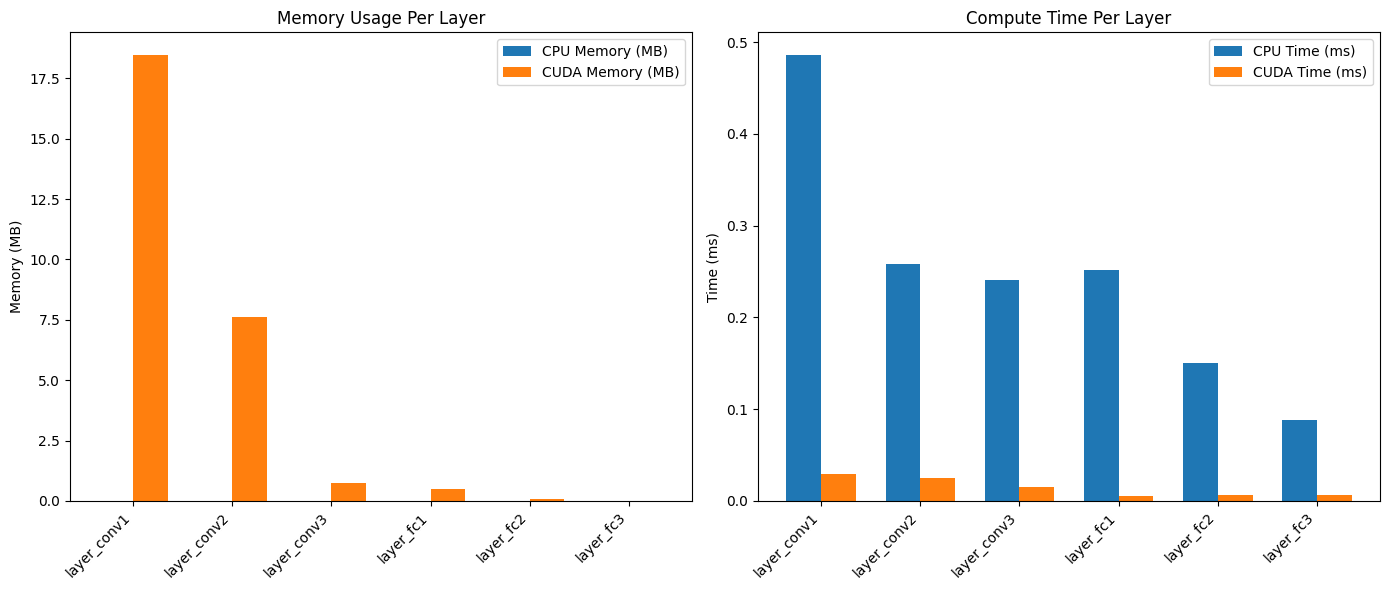

In [24]:
import numpy as np
from torch.profiler import profile, ProfilerActivity


profiler_results = []

def trace_handler(prof):
    profiler_results.append(prof.key_averages())

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=torch.profiler.schedule(wait=1, warmup=1, active=2),
    on_trace_ready=trace_handler,
    record_shapes=True,
    profile_memory=True,
    with_stack=True,
) as prof:
    for batch_idx, (data, target) in enumerate(train_loader):
        if batch_idx >= 4:
            break
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        prof.step()

layer_names = []
layer_cuda_memory_mb = []
layer_cpu_memory_mb = []
layer_cuda_compute_ms = []
layer_cpu_compute_ms = []

for event in profiler_results[-1]:
    if "layer_" in event.key and event.cpu_time_total > 0:
        print(event.key, event.cpu_time_total, event.device_memory_usage)
        layer_names.append(event.key)
        layer_cuda_memory_mb.append(event.device_memory_usage / (1024 ** 2))
        layer_cpu_memory_mb.append(event.cpu_memory_usage / (1024 ** 2))
        layer_cuda_compute_ms.append(event.device_time_total / 1000)
        layer_cpu_compute_ms.append(event.cpu_time_total / 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(layer_names))
width = 0.35

ax1.bar(x - width/2, layer_cpu_memory_mb, width, label='CPU Memory (MB)')
ax1.bar(x + width/2, layer_cuda_memory_mb, width, label='CUDA Memory (MB)')
ax1.set_ylabel('Memory (MB)')
ax1.set_title('Memory Usage Per Layer')
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names, rotation=45, ha='right')
ax1.legend()

ax2.bar(x - width/2, layer_cpu_compute_ms, width, label='CPU Time (ms)')
ax2.bar(x + width/2, layer_cuda_compute_ms, width, label='CUDA Time (ms)')
ax2.set_ylabel('Time (ms)')
ax2.set_title('Compute Time Per Layer')
ax2.set_xticks(x)
ax2.set_xticklabels(layer_names, rotation=45, ha='right')
ax2.legend()

fig.tight_layout()
plt.show()

fig.savefig("layer_profile.svg", format="svg")